In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Notebook display
%matplotlib inline

# Style settings
sns.set_style("whitegrid")
sns.set_palette("deep")

print("Libraries Imported Successfully ✅")


Libraries Imported Successfully ✅


In [4]:
# Load Dataset
df = pd.read_csv("sales_data.csv")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset Loaded Successfully ✅")


Dataset Loaded Successfully ✅


In [5]:
df.head()


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         100 non-null    datetime64[ns]
 1   Product      100 non-null    object        
 2   Quantity     100 non-null    int64         
 3   Price        100 non-null    int64         
 4   Customer_ID  100 non-null    object        
 5   Region       100 non-null    object        
 6   Total_Sales  100 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 5.6+ KB


In [7]:
df.describe()


,Date,Quantity,Price,Total_Sales
count,100,100.000000,100.000000,100.000000
mean,2024-02-19 12:00:00,4.780000,25808.510000,123650.480000
min,2024-01-01 00:00:00,1.000000,1308.000000,6540.000000
25%,2024-01-25 18:00:00,2.750000,14965.250000,39517.500000
50%,2024-02-19 12:00:00,5.000000,24192.000000,97955.500000
75%,2024-03-15 06:00:00,7.000000,38682.250000,175792.500000
max,2024-04-09 00:00:00,9.000000,49930.000000,373932.000000
std,NaN,2.588163,13917.630242,100161.085275


In [8]:
df.isnull().sum()


Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

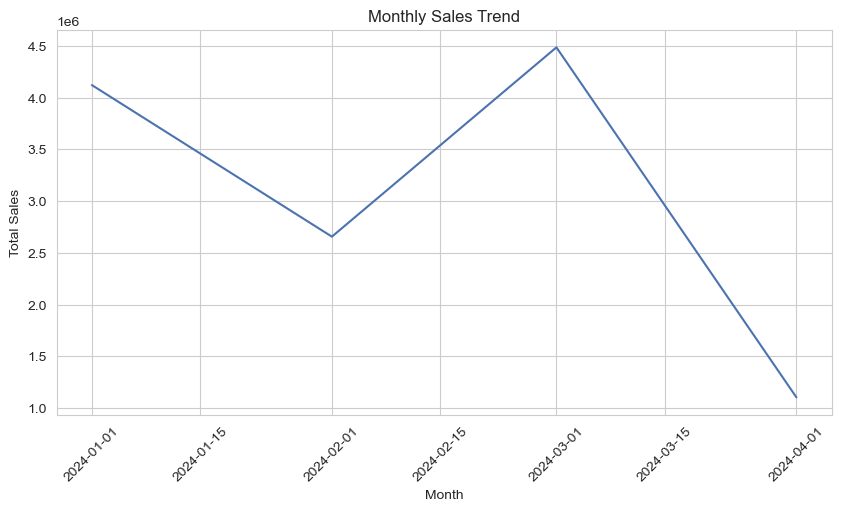

In [13]:
plt.figure(figsize=(10,5))

monthly_sales = df.groupby(df['Date'].dt.to_period("M"))['Total_Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()


<Figure size 800x500 with 0 Axes>

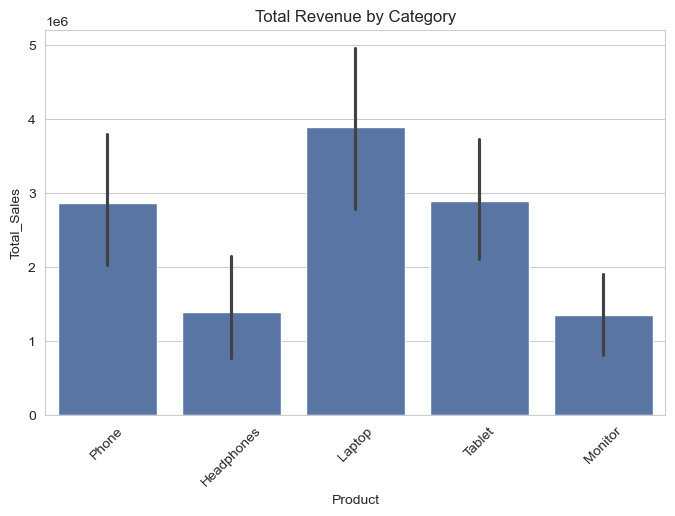

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Product',
    y='Total_Sales',
    data=df,
    estimator=sum
)

plt.title("Total Revenue by Category")
plt.xticks(rotation=45)
plt.show()


<Figure size 800x500 with 0 Axes>

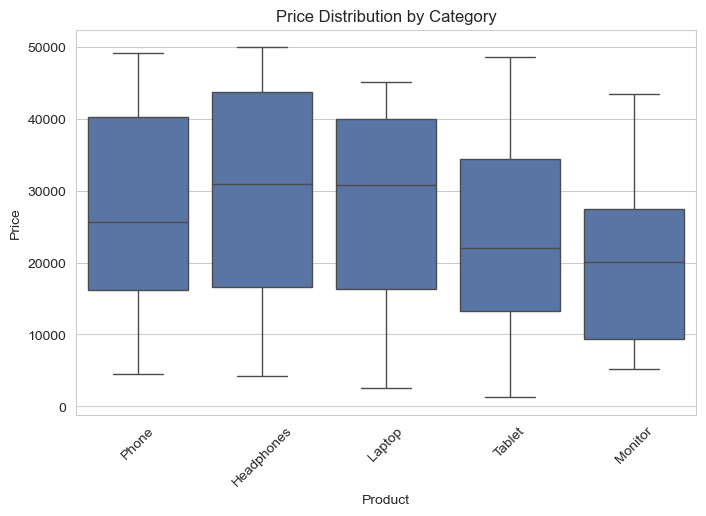

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Product', y='Price', data=df)

plt.title('Price Distribution by Category')
plt.xticks(rotation=45)
plt.show()


In [18]:
df.columns


Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

<Figure size 800x500 with 0 Axes>

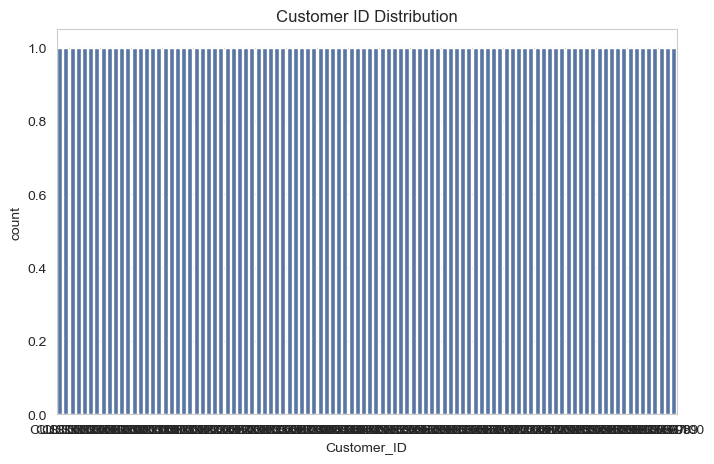

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x='Customer_ID', data=df)

plt.title("Customer ID Distribution")
plt.show()


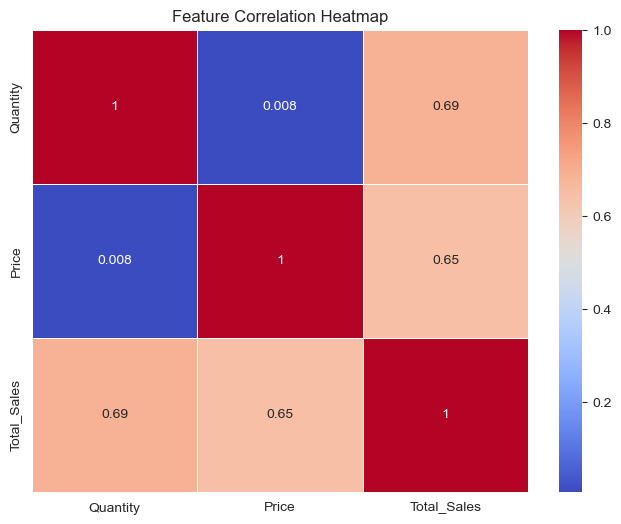

In [22]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()


In [24]:
monthly_sales_plotly = (
    df.groupby(df['Date'].dt.to_period("M"))['Total_Sales']
    .sum()
    .reset_index()
)

monthly_sales_plotly['Date'] = monthly_sales_plotly['Date'].dt.to_timestamp()

fig1 = px.line(
    monthly_sales_plotly,
    x='Date',
    y='Total_Sales',
    title='Interactive Monthly Sales Trend',
    markers=True,
    template='plotly_white'
)

fig1.show()


In [26]:
fig2 = px.pie(
    df,
    names='Customer_ID',
    title='Customer_ID Breakdown',
    template='plotly_white'
)

fig2.show()


In [28]:
fig3 = px.bar(
    df,
    x='Product',
    y='Total_Sales',
    color='Product',
    title='Product Performance',
    template='plotly_white'
)

fig3.update_layout(xaxis_tickangle=-45)
fig3.show()


In [29]:
total_sales = df['Total_Sales'].sum()
total_customers = df['Customer_ID'].nunique()
best_product = df.groupby('Product')['Total_Sales'].sum().idxmax()

print("📊 DASHBOARD SUMMARY")
print("----------------------------")
print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Customers: {total_customers}")
print(f"Best Selling Product: {best_product}")


📊 DASHBOARD SUMMARY
----------------------------
Total Sales: ₹12,365,048.00
Total Customers: 100
Best Selling Product: Laptop
